## Introduction

This analysis explores climate data for Ethiopia as part of the African Climate Trends study in preparation for COP32.

The objective is to clean the dataset, perform exploratory data analysis (EDA), and extract meaningful insights about temperature, rainfall, humidity, and wind patterns over time (2015–2026).

This helps to understand seasonal variations and long-term climate behavior.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

In [9]:
df = pd.read_csv("../data/ethiopia.csv")

# Add country column
df["Country"] = "Ethiopia"

# Convert YEAR + DOY → Date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

In [10]:
# Replace NASA missing values
df.replace(-999, np.nan, inplace=True)

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values count
print(df.isna().sum())

# Missing percentage
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent)

Duplicates: 0
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64


In [11]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [12]:
cols = [
    'T2M', 'T2M_MAX', 'T2M_MIN',
    'PRECTOTCORR', 'RH2M', 'WS2M'
]

z_scores = np.abs(df[cols].apply(zscore))

outlier_counts = (z_scores > 3).sum()
print(outlier_counts)

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
dtype: int64


In [24]:
# Drop rows with >30% missing values
# Drop rows with >30% missing values
df = df[df.isna().mean(axis=1) < 0.3]

# Sort by date (important for time series)
df["date"] = pd.to_datetime(df["YEAR"].astype(str) + df["DOY"].astype(str), format="%Y%j")
df = df.sort_values("Date")

# Forward fill (NEW pandas syntax)
df = df.ffill()

In [25]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

<Axes: title={'center': 'Monthly Average Temperature'}, xlabel='Month'>

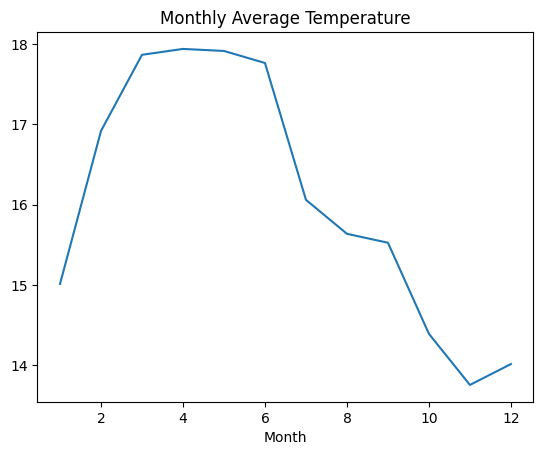

In [26]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(title="Monthly Average Temperature")

<Axes: title={'center': 'Monthly Rainfall'}, xlabel='Month'>

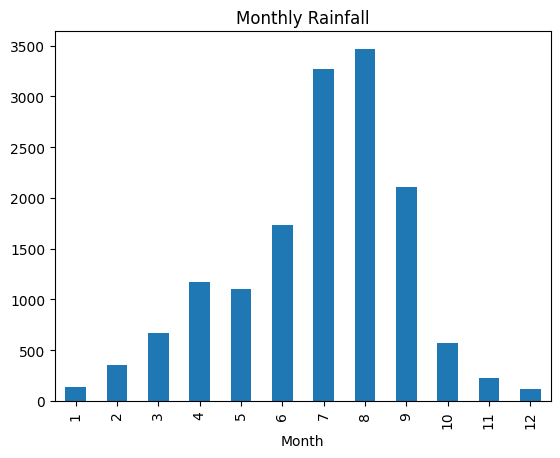

In [27]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", title="Monthly Rainfall")

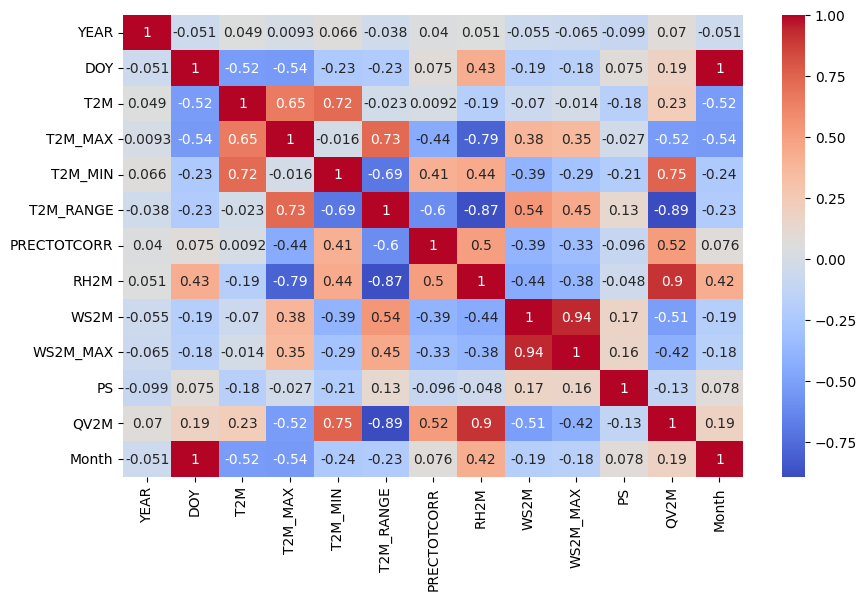

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

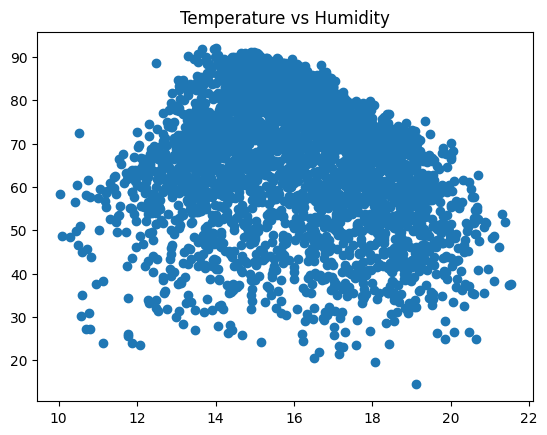

In [29]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

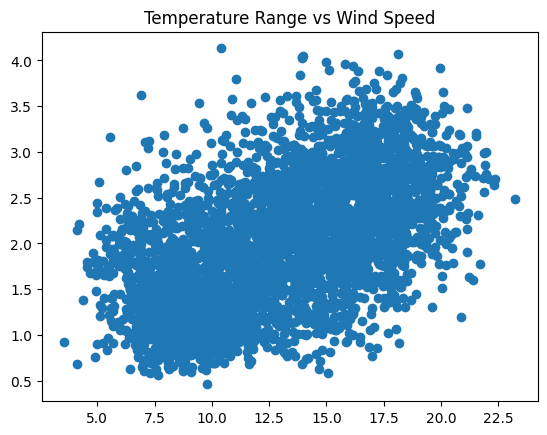

In [30]:
t_range = df["T2M_MAX"] - df["T2M_MIN"]

plt.scatter(t_range, df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.show()

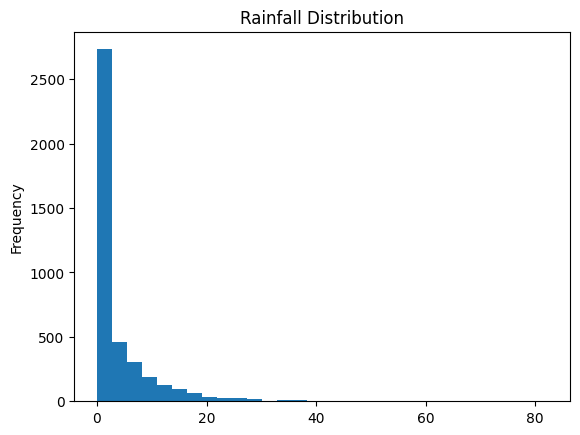

In [31]:
df["PRECTOTCORR"].plot(kind="hist", bins=30, title="Rainfall Distribution")
plt.show()

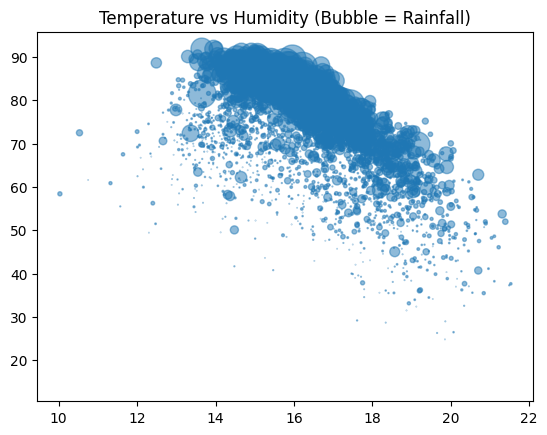

In [32]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 10,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()

## Conclusion

The exploratory data analysis of Ethiopia’s climate dataset reveals:

- Strong seasonal temperature patterns
- Distinct rainy and dry seasons
- Negative relationship between temperature and humidity
- Presence of extreme weather events

These insights are important for understanding climate variability in Ethiopia and contribute to broader African climate trend analysis for COP32 discussions.